# A First Look at Rust, for Python Users

In part 1 you measured the same query in Pandas, Polars, and PySpark. Polars
was several times faster than Pandas on the same file, on the same machine,
doing the same work.

Polars is written in Rust.

That is the reason for this notebook. You are not here to become a Rust
programmer in twenty minutes — you are here to see the handful of ideas that
let a library like Polars be that much faster, and to see them *run* rather
than hear them described.

**What you will do**

1. Compile a program, and meet the step Python does not have.
2. Watch the compiler refuse to let a variable change.
3. Watch memory get freed at a moment you can point to in the source.
4. Give a value away, and try to use it afterwards.
5. Break the rule that says one writer or many readers, never both.
6. Run a loop on all your cores, and watch Python decline to.
7. Time the same group-by in both languages, then in Polars.

Four of the programs below are *expected to fail*, and those four are the
point: in Rust a whole category of bug is a compile error, and a compile error
is a thing that never reaches your users.

## Before you start

Install Rust with `rustup`, which is the official installer:

```bash
# macOS and Linux
curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh

# Windows: download and run rustup-init.exe from https://rustup.rs
```

Then open a new terminal and check it:

```bash
rustc --version
```

On macOS `brew install rust` also works. You do **not** need a new Jupyter
kernel — this notebook runs on the same **Dataframe Engines** kernel from part
1 and calls `rustc` for you.

Every Rust file used below is a real file in `rust/examples/`, so you can keep
working on them after class:

```bash
make rust          # compile and run all the working examples
make rust-errors   # compile the ones that are supposed to fail
```


In [1]:
import gc
import os
import platform
import re
import shutil
import subprocess
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="notebook")
SECONDS = FuncFormatter(lambda v, _: f"{v * 1000:g} ms" if v < 1 else f"{v:g} s")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EXAMPLES = ROOT / "rust" / "examples"
BUILD = ROOT / "rust" / "build"
BUILD.mkdir(parents=True, exist_ok=True)

RUSTC = shutil.which("rustc")
EDITION = "2024"


def _resolve(name):
    """Accepts '02_variables' or 'wont_compile/use_after_move'."""
    path = EXAMPLES / f"{name}.rs"
    if not path.exists():
        raise FileNotFoundError(f"no such example: {path}")
    return path


def show_source(name):
    """Display a Rust file the way it sits on disk."""
    path = _resolve(name)
    body = path.read_text().rstrip()
    display(Markdown(f"`{path.relative_to(ROOT)}`\n```rust\n{body}\n```"))


_BLOCK_START = re.compile(r"^(error|warning|note|help)\b")


def _tidy(message):
    """Drop the note blocks that point into Rust's own source, not yours."""
    blocks, current = [], []
    for line in message.splitlines():
        if _BLOCK_START.match(line) and current:
            blocks.append(current)
            current = [line]
        else:
            current.append(line)
    if current:
        blocks.append(current)
    keep = [
        b
        for b in blocks
        if not (b[0].startswith("note:") and any("rustlib" in l for l in b))
    ]
    return "\n".join("\n".join(b) for b in keep).strip()


def compile_rust(name, optimize=True):
    """Compile one file. Returns (binary or None, compiler output, seconds)."""
    path = _resolve(name)
    suffix = "" if optimize else "-debug"
    binary = (BUILD / (path.stem + suffix)).resolve()
    command = [RUSTC, "--edition", EDITION, path.name, "-o", str(binary)]
    if optimize:
        command.insert(1, "-O")
    start = time.perf_counter()
    # Compile from the file's own directory so errors name the file, not its path.
    done = subprocess.run(command, capture_output=True, text=True, cwd=path.parent)
    seconds = time.perf_counter() - start
    return (binary if done.returncode == 0 else None, _tidy(done.stderr), seconds)


def run_rust(name, args=(), optimize=True, source=False):
    """Compile and run an example, printing whatever it prints."""
    if source:
        show_source(name)
    binary, message, compile_seconds = compile_rust(name, optimize=optimize)
    if binary is None:
        print(message)
        raise RuntimeError(f"{name} was expected to compile, but did not")
    mode = "release" if optimize else "debug"
    print(f"compiled {name}.rs in {compile_seconds:.2f} s ({mode})\n")
    done = subprocess.run(
        [str(binary), *[str(a) for a in args]], capture_output=True, text=True
    )
    print(done.stdout.rstrip())
    if done.stderr.strip():
        print(done.stderr.rstrip())
    return done.stdout


def expect_compile_error(name):
    """Compile something that must not compile, and show why."""
    show_source(name)
    binary, message, _ = compile_rust(name)
    if binary is not None:
        raise RuntimeError(f"{name} compiled, but was supposed to fail")
    print(message)


if RUSTC is None:
    print("rustc was not found. Install Rust (see the cell above), then restart")
    print("this kernel. Every Rust cell below will fail until then.")
else:
    version = subprocess.run(
        [RUSTC, "--version"], capture_output=True, text=True
    ).stdout.strip()
    print(version)

print(f"Python {platform.python_version()}")
print(f"{platform.machine()} {platform.system()}, {os.cpu_count()} cores")
print(f"GIL enabled: {getattr(sys, '_is_gil_enabled', lambda: True)()}")

rustc 1.98.0 (88d9e12ae 2026-08-18) (Homebrew)
Python 3.14.3
arm64 Darwin, 12 cores
GIL enabled: True


## 1. The step Python does not have

Python reads your file and runs it. A mistake on line 400 is discovered when
line 400 runs — which might be tonight, in production, on someone else's data.

Rust reads the *whole* program first, checks it, and only then produces a
binary. If anything is wrong there is no binary to run. You pay for this with
compile time, and you are paid back in bugs that cannot happen.

Run the cell below. It shows the file, compiles it, and runs the result.


In [2]:
run_rust("01_hello", source=True)

`rust/examples/01_hello.rs`
```rust
// Rust has a step Python does not: the compiler runs before the program does.
//
//   rustc --edition 2024 01_hello.rs -o hello   # compile once
//   ./hello                                     # run as often as you like

fn main() {
    let engine = "Rust";
    let year = 2026;

    println!("Hello from {engine}, {year}.");
    println!("This file was checked by the compiler before it ran.");
}
```

compiled 01_hello.rs in 0.08 s (release)



Hello from Rust, 2026.
This file was checked by the compiler before it ran.


'Hello from Rust, 2026.\nThis file was checked by the compiler before it ran.\n'

Two things worth noticing about what just happened.

The compile took a moment; running took none. That binary now starts instantly
and needs no interpreter, no virtual environment, and no Rust installation on
the machine that runs it.

And it is a *binary*. When you `pip install polars`, you are not downloading
Python — you are downloading a compiled Rust library with a thin Python layer
on top.


## 2. Immutable unless you ask

In Python every name can be pointed at something new, whenever you like. In
Rust `let` binds a value that will not change, and you must write `let mut` to
say otherwise.

This is not a style preference. `mut` is how you tell the compiler which parts
of your program are allowed to change, and everything in section 5 is built on
it knowing that.


In [3]:
run_rust("02_variables", source=True)

`rust/examples/02_variables.rs`
```rust
// Variables are immutable unless you say otherwise.
// In Python every name can be reassigned; in Rust that is opt-in.

fn main() {
    // Immutable: the value is fixed once bound.
    let min_ratings = 1000;
    println!("min_ratings = {min_ratings}");

    // Mutable: `mut` is you telling the compiler this will change.
    let mut rows_read = 0;
    for _ in 0..3 {
        rows_read += 100_000;
    }
    println!("rows_read  = {rows_read}");

    // Shadowing: a new `let` makes a *new* variable reusing the name.
    // Useful for converting a value without inventing a second name.
    let threshold = "4.5";
    let threshold: f64 = threshold.parse().expect("not a number");
    println!("threshold  = {threshold} (now an f64, not a string)");

    // The type is fixed at compile time even though we never wrote it down.
    let average = 3.7;
    println!("average    = {average} inferred as f64");
}
```

compiled 02_variables.rs in 0.10 s (release)



min_ratings = 1000
rows_read  = 300000
threshold  = 4.5 (now an f64, not a string)
average    = 3.7 inferred as f64


'min_ratings = 1000\nrows_read  = 300000\nthreshold  = 4.5 (now an f64, not a string)\naverage    = 3.7 inferred as f64\n'

Now the same thing done wrong. The file below assigns to a variable that was
never declared `mut`. Read the error carefully — it points at both lines, says
which is the problem, and tells you the fix.


In [4]:
expect_compile_error("wont_compile/assign_to_immutable")

`rust/examples/wont_compile/assign_to_immutable.rs`
```rust
// EXPECTED TO FAIL: error[E0384]
//
// `let` alone means immutable. Python has no equivalent of this error --
// there, every name can be pointed at something new at any time.
//
// Fix: `let mut limit = 1000;`

fn main() {
    let limit = 1000;
    println!("limit starts at {limit}");

    limit = 2000;
    println!("limit is now {limit}");
}
```

error[E0384]: cannot assign twice to immutable variable `limit`
  --> assign_to_immutable.rs:12:5
   |
 9 |     let limit = 1000;
   |         ----- first assignment to `limit`
...
12 |     limit = 2000;
   |     ^^^^^^^^^^^^ cannot assign twice to immutable variable
   |
help: consider making this binding mutable
   |
 9 |     let mut limit = 1000;
   |         +++

error: aborting due to 1 previous error

For more information about this error, try `rustc --explain E0384`.


In Python the equivalent code is simply correct, so nothing can warn you:


In [5]:
limit = 1000
print("limit starts at", limit)
limit = 2000
print("limit is now", limit, "- Python never objected")

# The nearest equivalent Python has is a frozen dataclass, and even that is
# checked when the line runs, not when the file is read.
from dataclasses import FrozenInstanceError, dataclass


@dataclass(frozen=True)
class Config:
    min_ratings: int


config = Config(min_ratings=1000)
try:
    config.min_ratings = 2000
except FrozenInstanceError as error:
    print(f"\nfrozen dataclass: {error!r}")
    print("caught at runtime, on the line that ran - not before the program started")

limit starts at 1000
limit is now 2000 - Python never objected

frozen dataclass: FrozenInstanceError("cannot assign to field 'min_ratings'")
caught at runtime, on the line that ran - not before the program started


## 3. Where the memory goes

This is the part that matters most for a data engineer, because it is where
the speed comes from.

Rust has no garbage collector and does no reference counting at runtime. The
compiler works out where each value stops being used and puts the `free`
there, while compiling. At runtime there is no bookkeeping left to do — no
counters to increment, no pauses, no collector thread.

You can watch it happen. Rust lets a type say what should happen when it is
dropped, so the example below prints at the exact moment its memory is
released. Nobody calls that code; the compiler placed the call.


In [6]:
run_rust("03_scope_memory", source=True)

`rust/examples/03_scope_memory.rs`
```rust
// Where does the memory go?
//
// There is no garbage collector here and no reference counting at runtime.
// The compiler knows where each value stops being used and puts the free
// there. `Drop` lets us print at that exact moment so it is visible.

struct Buffer {
    name: &'static str,
    bytes: Vec<u8>,
}

impl Buffer {
    fn new(name: &'static str, megabytes: usize) -> Buffer {
        println!("  allocate {name}: {megabytes} MB");
        Buffer {
            name,
            bytes: vec![0u8; megabytes * 1024 * 1024],
        }
    }
}

// Runs automatically when the value goes out of scope. You never call it.
impl Drop for Buffer {
    fn drop(&mut self) {
        let megabytes = self.bytes.len() / (1024 * 1024);
        println!("  FREE {}: {} MB released", self.name, megabytes);
    }
}

fn main() {
    println!("enter main");

    {
        println!("enter inner scope");
        let _scratch = Buffer::new("scratch", 64);
        println!("inner scope is about to end");
    } // <- the free happens here, on this closing brace

    println!("back in main: scratch is already gone");

    let _a = Buffer::new("a", 8);
    let _b = Buffer::new("b", 16);

    println!("end of main (watch the order)");
    // Values drop in reverse order of creation: b, then a.
}
```

compiled 03_scope_memory.rs in 0.10 s (release)



enter main
enter inner scope
  allocate scratch: 64 MB
inner scope is about to end
  FREE scratch: 64 MB released
back in main: scratch is already gone
  allocate a: 8 MB
  allocate b: 16 MB
end of main (watch the order)
  FREE b: 16 MB released
  FREE a: 8 MB released


'enter main\nenter inner scope\n  allocate scratch: 64 MB\ninner scope is about to end\n  FREE scratch: 64 MB released\nback in main: scratch is already gone\n  allocate a: 8 MB\n  allocate b: 16 MB\nend of main (watch the order)\n  FREE b: 16 MB released\n  FREE a: 8 MB released\n'

Read the output next to the source. `scratch` is freed on the closing brace of
the inner scope — not at the end of the program, and not whenever a collector
next feels like running. And `a` and `b` drop in reverse order of creation,
because that is the order in which the compiler wrote the calls.

**To be fair to Python:** CPython also frees promptly most of the time, by
counting references and dropping a value when the count hits zero. The
differences are that Python does that counting at runtime, on every assignment,
and that counting alone cannot free a cycle — so there is a second collector
for those. Run the cell below and watch the two cases behave differently.


In [7]:
class Buffer:
    def __init__(self, name, megabytes):
        self.name = name
        self.data = bytearray(megabytes * 1024 * 1024)
        self.friend = None
        print(f"  allocate {name}: {megabytes} MB")

    def __del__(self):
        print(f"  FREE {self.name}: {len(self.data) // 1024**2} MB released")


print("no cycle -- reference counting frees it the moment the last name goes:")
simple = Buffer("simple", 64)
del simple
print("  (that FREE printed above, before this line)\n")

print("a cycle -- the two buffers hold each other:")
left = Buffer("cycle-a", 64)
right = Buffer("cycle-b", 64)
left.friend, right.friend = right, left
del left, right
print("  both names are gone, and nothing has been freed")
print("  calling the cycle collector by hand:")
print(f"  gc.collect() reclaimed {gc.collect()} objects")

no cycle -- reference counting frees it the moment the last name goes:
  allocate simple: 64 MB
  FREE simple: 64 MB released
  (that FREE printed above, before this line)

a cycle -- the two buffers hold each other:
  allocate cycle-a: 64 MB
  allocate cycle-b: 64 MB
  both names are gone, and nothing has been freed
  calling the cycle collector by hand:
  FREE cycle-a: 64 MB released
  FREE cycle-b: 64 MB released
  gc.collect() reclaimed 2 objects


Both buffers stayed alive with no way to reach them, until a collector came
looking. In a long-running service that is where memory footprint comes from,
and it is why tuning `gc` is a thing people do.

You cannot reach that situation by accident in Rust. A cycle needs shared
ownership, and shared ownership is a type you have to ask for by name — `Rc`.
A cycle of `Rc`s genuinely does leak, and the fix is to make one side a `Weak`
reference. So the claim is not that Rust cannot leak memory; it is that the
default cannot, and that you have to type the name of the thing that can.


## 4. Ownership: one owner per value

Here is the rule the whole language is built on:

> Every value has exactly one owner. When the owner goes out of scope, the
> value is freed.

That is what makes section 3 possible. If there is always exactly one owner,
the compiler always knows where the `free` belongs.

So what happens when you write `b = a`? Python gives you a second name for the
same object. Rust *moves* the value: `b` is now the owner and `a` is no longer
usable. If you wanted a copy you say `clone()`, and you can see the cost in
the source.


In [8]:
run_rust("04_ownership", source=True)

`rust/examples/04_ownership.rs`
```rust
// Ownership: every value has exactly one owner.
//
// This is the rule that replaces the garbage collector. If there is always
// one owner, the compiler always knows where the free belongs.

fn summarize(ratings: &Vec<f64>) -> f64 {
    // Borrowed, not owned: this function may look, not keep.
    ratings.iter().sum::<f64>() / ratings.len() as f64
}

fn consume(ratings: Vec<f64>) -> usize {
    // Owned: this function took the value and will free it when it returns.
    ratings.len()
}

fn main() {
    let ratings = vec![4.5, 3.0, 5.0, 2.5];

    // 1. Borrow with `&`. `ratings` still belongs to main afterwards.
    println!("average      = {:.2}", summarize(&ratings));
    println!("still usable = {ratings:?}");

    // 2. Move. Assigning transfers ownership instead of copying the data.
    let moved = ratings;
    println!("moved        = {moved:?}");
    // Using `ratings` here would not compile -- see wont_compile/use_after_move.rs

    // 3. Clone when you genuinely want a second copy. The cost is explicit.
    let copy = moved.clone();
    println!("clone        = {copy:?}");

    // 4. Give a value away for good.
    println!("consume took {} values", consume(moved));
    // `moved` is gone now; `copy` is untouched.
    println!("copy survives: {copy:?}");
}
```

compiled 04_ownership.rs in 0.11 s (release)



average      = 3.75
still usable = [4.5, 3.0, 5.0, 2.5]
moved        = [4.5, 3.0, 5.0, 2.5]
clone        = [4.5, 3.0, 5.0, 2.5]
consume took 4 values
copy survives: [4.5, 3.0, 5.0, 2.5]


'average      = 3.75\nstill usable = [4.5, 3.0, 5.0, 2.5]\nmoved        = [4.5, 3.0, 5.0, 2.5]\nclone        = [4.5, 3.0, 5.0, 2.5]\nconsume took 4 values\ncopy survives: [4.5, 3.0, 5.0, 2.5]\n'

Now use a value after giving it away:


In [9]:
expect_compile_error("wont_compile/use_after_move")

`rust/examples/wont_compile/use_after_move.rs`
```rust
// EXPECTED TO FAIL: error[E0382]
//
// `let second = first;` moves ownership. There is no longer a valid `first`.
//
// In Python the same two lines give you two names for one list, which is
// where aliasing bugs come from: mutate through `second` and `first` changes
// too, silently. Rust makes you choose -- move it, borrow it, or clone it.
//
// Fix: `let second = first.clone();` or read through a borrow.

fn main() {
    let first = vec![1, 2, 3];
    let second = first;

    println!("{first:?} {second:?}");
}
```

error[E0382]: borrow of moved value: `first`
  --> use_after_move.rs:15:16
   |
12 |     let first = vec![1, 2, 3];
   |         ----- move occurs because `first` has type `Vec<i32>`, which does not implement the `Copy` trait
13 |     let second = first;
   |                  ----- value moved here
14 |
15 |     println!("{first:?} {second:?}");
   |                ^^^^^ value borrowed here after move
   |
help: consider cloning the value if the performance cost is acceptable
   |
13 |     let second = first.clone();
   |                       ++++++++

error: aborting due to 1 previous error

For more information about this error, try `rustc --explain E0382`.


Notice the compiler even offers the fix: `first.clone()`.

The Python version of those same two lines runs without complaint, and this is
one of the most common bugs in real data code:


In [10]:
first = [1, 2, 3]
second = first
second.append(4)

print("first  =", first)
print("second =", second)
print("one list, two names -- and appending through one changed 'both'")

first = [1, 2, 3]
second = first.copy()
second.append(4)
print("\nwith .copy():")
print("first  =", first)
print("second =", second)
print("correct -- but you had to know to write it, and nothing reminded you")

first  = [1, 2, 3, 4]
second = [1, 2, 3, 4]
one list, two names -- and appending through one changed 'both'

with .copy():
first  = [1, 2, 3]
second = [1, 2, 3, 4]
correct -- but you had to know to write it, and nothing reminded you


## 5. Borrowing: one writer or many readers

Moving a value every time you pass it around would be exhausting, so you can
lend it instead. There are exactly two ways, and the difference is the whole
game:

| | Meaning | How many at once |
|---|---|---|
| `&T` | shared borrow, read only | as many as you like |
| `&mut T` | exclusive borrow, may write | exactly one |

One writer, or many readers, never both at the same time. The compiler checks
this — the part of it that does is called the borrow checker.


In [11]:
run_rust("05_borrow_rules", source=True)

`rust/examples/05_borrow_rules.rs`
```rust
// Borrowing has exactly two forms, and the compiler enforces the difference.
//
//   &T      shared borrow      -- many at once, read only
//   &mut T  exclusive borrow   -- one at a time, may write
//
// One writer or many readers, never both. That single rule is what makes
// the data races in example 06 impossible rather than merely unlikely.

fn average(values: &[u64]) -> f64 {
    values.iter().sum::<u64>() as f64 / values.len() as f64
}

fn highest(values: &[u64]) -> u64 {
    *values.iter().max().unwrap()
}

fn add_rating(values: &mut Vec<u64>, rating: u64) {
    values.push(rating);
}

fn main() {
    let mut ratings = vec![5, 3, 4, 4];

    // Many shared borrows at the same time: fine, nobody is writing.
    let a = &ratings;
    let b = &ratings;
    println!("two readers agree: {:?} == {:?}", a, b);
    println!("average = {:.2}, highest = {}", average(a), highest(b));

    // The exclusive borrow starts here, after the readers are done with.
    add_rating(&mut ratings, 2);
    println!("after write: {ratings:?}");

    // Mutating a collection you are iterating is a real bug in Python and a
    // compile error here. The fix is to decide *first*, then write.
    let to_drop: Vec<usize> = ratings
        .iter()
        .enumerate()
        .filter(|&(_, &r)| r < 3)
        .map(|(i, _)| i)
        .collect();
    println!("plan: remove positions {to_drop:?}");

    for index in to_drop.into_iter().rev() {
        ratings.remove(index);
    }
    println!("after removal: {ratings:?}");
}
```

compiled 05_borrow_rules.rs in 0.14 s (release)



two readers agree: [5, 3, 4, 4] == [5, 3, 4, 4]
average = 4.00, highest = 5
after write: [5, 3, 4, 4, 2]
plan: remove positions [4]
after removal: [5, 3, 4, 4]


'two readers agree: [5, 3, 4, 4] == [5, 3, 4, 4]\naverage = 4.00, highest = 5\nafter write: [5, 3, 4, 4, 2]\nplan: remove positions [4]\nafter removal: [5, 3, 4, 4]\n'

The end of that example did something slightly awkward: it worked out which
items to remove, collected the positions, and only then removed them. The
obvious version — remove them while looping — does not compile, because the
loop is holding a shared borrow the whole time.


In [12]:
expect_compile_error("wont_compile/mutate_while_iterating")

`rust/examples/wont_compile/mutate_while_iterating.rs`
```rust
// EXPECTED TO FAIL: error[E0502]
//
// `for r in &ratings` holds a shared borrow for the whole loop, so nothing
// may write to `ratings` until the loop ends.
//
// The same code in Python runs happily and gives a wrong answer, because the
// iterator is walking a list that is changing underneath it.
//
// Fix: collect the changes first, apply them after -- see 05_borrow_rules.rs.

fn main() {
    let mut ratings = vec![5, 3, 4];

    for r in &ratings {
        if *r == 3 {
            ratings.push(0);
        }
    }

    println!("{ratings:?}");
}
```

error[E0502]: cannot borrow `ratings` as mutable because it is also borrowed as immutable
  --> mutate_while_iterating.rs:16:13
   |
14 |     for r in &ratings {
   |              --------
   |              |
   |              immutable borrow occurs here
   |              immutable borrow later used here
15 |         if *r == 3 {
16 |             ratings.push(0);
   |             ^^^^^^^^^^^^^^^ mutable borrow occurs here

error: aborting due to 1 previous error

For more information about this error, try `rustc --explain E0502`.


Here is why that rule is worth the awkwardness. The same idea in Python runs
fine and quietly gives you the wrong answer:


In [13]:
ratings = [5, 2, 2, 4]
print("before:", ratings)

for rating in ratings:
    if rating < 3:
        ratings.remove(rating)

print("after: ", ratings)
print("\nBoth 2s should be gone. One survived: removing an item shifted the")
print("list left while the loop kept walking forward, so an index was skipped.")
print("No exception, no warning. Just a wrong number in a report.")

before: [5, 2, 2, 4]
after:  [5, 2, 4]

Both 2s should be gone. One survived: removing an item shifted the
list left while the loop kept walking forward, so an index was skipped.
No exception, no warning. Just a wrong number in a report.


## 6. Concurrency: all of your cores

Your machine has several cores. In CPython, threads cannot use them for
computation, because only one thread may execute Python bytecode at a time —
the Global Interpreter Lock. Threads still help when you are waiting on a
network or a disk, but not when you are adding numbers.

Rust has no interpreter and no such lock. And the borrow-checking rule from
section 5 turns out to be exactly the rule that makes threads safe: if only
one thing may write to a value at a time, two threads cannot race on it.

The example below splits one CPU-bound total across 1, 2, 4, and 8 threads.
Each thread gets its own slice of the range, so there is nothing to lock — and
the compiler is what guarantees the slices do not overlap.


In [14]:
rust_threads = run_rust("06_threads", source=True)

`rust/examples/06_threads.rs`
```rust
// Concurrency: real cores, no interpreter lock.
//
// The same CPU-bound total is computed with 1, 2, 4, and 8 threads. Each
// thread owns a disjoint slice of the range, so there is nothing to lock --
// and the compiler is what confirms the slices are disjoint.
//
// Usage: 06_threads [iterations]

use std::thread;
use std::time::Instant;

const DEFAULT_ITERATIONS: u64 = 1_000_000_000;
const MODULUS: u64 = 1_000_003;

/// Deliberately cheap-but-not-free arithmetic the optimizer cannot fold away.
fn partial_sum(from: u64, to: u64) -> u64 {
    let mut total = 0;
    for i in from..to {
        total += (i * i) % MODULUS;
    }
    total
}

fn run(iterations: u64, threads: u64) -> (u64, f64) {
    let start = Instant::now();

    let total = thread::scope(|scope| {
        let chunk = iterations / threads;
        let handles: Vec<_> = (0..threads)
            .map(|t| {
                let from = t * chunk;
                let to = if t == threads - 1 {
                    iterations
                } else {
                    from + chunk
                };
                scope.spawn(move || partial_sum(from, to))
            })
            .collect();

        handles.into_iter().map(|h| h.join().unwrap()).sum::<u64>()
    });

    (total, start.elapsed().as_secs_f64())
}

fn main() {
    let iterations = std::env::args()
        .nth(1)
        .and_then(|a| a.parse().ok())
        .unwrap_or(DEFAULT_ITERATIONS);

    println!(
        "{iterations} iterations, {} cores available\n",
        thread::available_parallelism().map(|n| n.get()).unwrap_or(0)
    );
    println!("{:>7}  {:>9}  {:>8}  {}", "threads", "seconds", "speedup", "total");

    let mut baseline = 0.0;
    for threads in [1, 2, 4, 8] {
        let (total, seconds) = run(iterations, threads);
        if threads == 1 {
            baseline = seconds;
        }
        println!(
            "{threads:>7}  {seconds:>9.3}  {:>7.2}x  {total}",
            baseline / seconds
        );
    }

    println!("\nThe total is identical every time -- the work was split, not changed.");
}
```

compiled 06_threads.rs in 0.28 s (release)



1000000000 iterations, 12 cores available

threads    seconds   speedup  total
      1      0.412     1.00x  499896191210588
      2      0.205     2.01x  499896191210588
      4      0.106     3.88x  499896191210588
      8      0.062     6.61x  499896191210588

The total is identical every time -- the work was split, not changed.


Now the same shape of program in Python. It uses a smaller total, because a
Python loop is slower — the comparison to make is not the seconds, it is what
happens to the seconds as threads are added.


In [15]:
from concurrent.futures import ThreadPoolExecutor

PY_ITERATIONS = 24_000_000
MODULUS = 1_000_003


def partial_sum(span):
    start, stop = span
    total = 0
    for i in range(start, stop):
        total += (i * i) % MODULUS
    return total


def run_python(iterations, threads):
    chunk = iterations // threads
    spans = [
        (t * chunk, iterations if t == threads - 1 else t * chunk + chunk)
        for t in range(threads)
    ]
    start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=threads) as pool:
        total = sum(pool.map(partial_sum, spans))
    return total, time.perf_counter() - start


print(f"{PY_ITERATIONS:,} iterations in Python threads\n")
print(f"{'threads':>7}  {'seconds':>9}  {'speedup':>8}  total")

python_scaling = {}
baseline = None
for threads in (1, 2, 4, 8):
    total, seconds = run_python(PY_ITERATIONS, threads)
    baseline = baseline or seconds
    python_scaling[threads] = seconds
    print(f"{threads:>7}  {seconds:>9.3f}  {baseline / seconds:>7.2f}x  {total}")

24,000,000 iterations in Python threads

threads    seconds   speedup  total


      1      0.918     1.00x  11997539865492


      2      0.918     1.00x  11997539865492


      4      0.934     0.98x  11997539865492


      8      0.953     0.96x  11997539865492


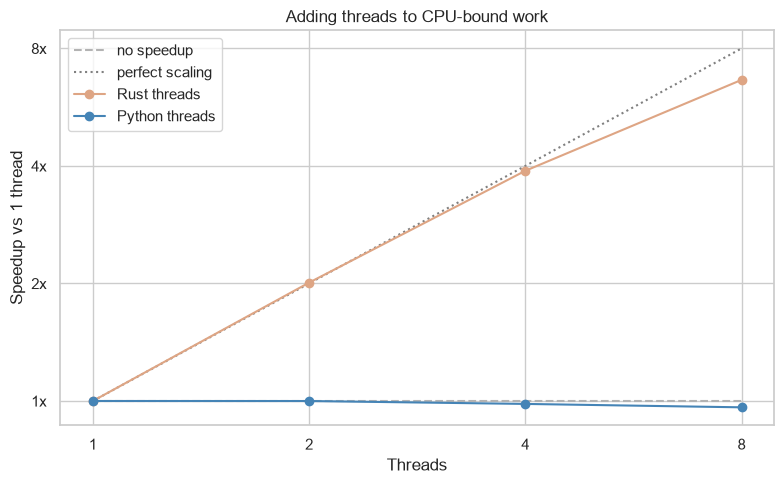

machine: arm64, 12 cores


In [16]:
# Pull the Rust numbers back out of the text it printed.
rust_scaling = {}
for line in rust_threads.splitlines():
    parts = line.split()
    if len(parts) == 4 and parts[0].isdigit():
        rust_scaling[int(parts[0])] = float(parts[1])

threads = sorted(rust_scaling)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threads, [1.0] * len(threads), "--", color="0.7", label="no speedup")
ax.plot(threads, threads, ":", color="0.5", label="perfect scaling")
for label, scaling, color in [
    ("Rust threads", rust_scaling, "#dea584"),
    ("Python threads", python_scaling, "#4584b6"),
]:
    base = scaling[1]
    ax.plot(
        threads,
        [base / scaling[t] for t in threads],
        marker="o",
        label=label,
        color=color,
    )
ax.set(
    xscale="log",
    yscale="log",
    xlabel="Threads",
    ylabel="Speedup vs 1 thread",
    title="Adding threads to CPU-bound work",
)
ax.set_xticks(threads, [str(t) for t in threads])
ax.set_yticks([1, 2, 4, 8], ["1x", "2x", "4x", "8x"])
ax.minorticks_off()
ax.legend()
fig.tight_layout()
plt.show()

print(f"machine: {platform.machine()}, {os.cpu_count()} cores")

Python's line is flat. Eight threads did the work in about the same time as
one, and often slightly worse, because the threads spend their time handing
the lock back and forth. Rust's line climbs — not perfectly, since these cores
are not all the same speed and memory bandwidth is finite, but it climbs.

Two honest footnotes. Python does have answers here: `multiprocessing` and
`ProcessPoolExecutor` use separate processes with separate locks, libraries
like NumPy and Polars release the GIL while their compiled code runs, and
Python 3.13 introduced an optional free-threaded build without the GIL. And
Rust does not make concurrency easy — it makes it *safe*, which is a different
claim.

Here is what safe means. This program has four threads writing to one counter:


In [17]:
expect_compile_error("wont_compile/shared_mutable_across_threads")

`rust/examples/wont_compile/shared_mutable_across_threads.rs`
```rust
// EXPECTED TO FAIL: error[E0499]
//
// Four threads each want to write to the same counter. That is a data race,
// and it is rejected at compile time -- not detected later, under load, in
// production, one run in a thousand.
//
// The equivalent Python code has the same bug. It usually appears to work,
// because the interpreter lock happens to serialize the increments.
//
// Fix: give each thread its own subtotal and add them up at the end
// (06_threads.rs), or wrap the counter in a Mutex or AtomicU64.

fn main() {
    let mut total = 0u64;

    std::thread::scope(|scope| {
        for _ in 0..4 {
            scope.spawn(|| {
                total += 1;
            });
        }
    });

    println!("{total}");
}
```

error[E0499]: cannot borrow `total` as mutable more than once at a time
   --> shared_mutable_across_threads.rs:18:25
    |
 16 |       std::thread::scope(|scope| {
    |                           ----- has type `&'1 Scope<'1, '_>`
 17 |           for _ in 0..4 {
 18 |               scope.spawn(|| {
    |               -           ^^ `total` was mutably borrowed here in the previous iteration of the loop
    |  _____________|
    | |
 19 | |                 total += 1;
    | |                 ----- borrows occur due to use of `total` in closure
 20 | |             });
    | |______________- argument requires that `total` is borrowed for `'1`
    |
error: aborting due to 1 previous error

For more information about this error, try `rustc --explain E0499`.


That is a data race, and it did not become a warning, a crash, or a wrong
total that shows up one run in a thousand under load. It became a compile
error, in the same breath as a typo.

The write-up of the equivalent Python bug would be a paragraph about how it
usually works fine.


## 7. The same group-by, both languages

Time to put a number on it. This is part 1's task, stripped of file formats:
generate five million ratings, group them by movie, keep the movies with at
least a hundred ratings, and report the best one.

Both versions generate their data from the same seed with the same arithmetic,
and both count ratings in half-stars so the totals are integers and cannot
drift. If the two answers do not match exactly, the comparison is void — a
fast wrong answer is still wrong.

The Rust file is `rust/examples/07_groupby.rs`. It is compiled twice, because
which way you compile it matters more than students usually expect.


In [18]:
ROWS, MOVIES, MIN_RATINGS = 5_000_000, 10_000, 100


def parse_output(text):
    fields = {}
    for line in text.splitlines():
        key, _, value = line.partition(" ")
        fields[key] = value.strip()
    return fields


print("=== Rust, compiled without optimization (the default) ===")
debug = parse_output(run_rust("07_groupby", args=(ROWS, MOVIES), optimize=False))
print("\n=== Rust, compiled with -O (what a release build does) ===")
release = parse_output(run_rust("07_groupby", args=(ROWS, MOVIES), optimize=True))

=== Rust, compiled without optimization (the default) ===


compiled 07_groupby.rs in 0.11 s (debug)



rows               5000000
movies             10000
qualifying_movies  10000
best_movie         1315
best_average       3.225490
checksum           29995959
generate_seconds   0.0484
aggregate_seconds  0.0503

=== Rust, compiled with -O (what a release build does) ===
compiled 07_groupby.rs in 0.19 s (release)



rows               5000000
movies             10000
qualifying_movies  10000
best_movie         1315
best_average       3.225490
checksum           29995959
generate_seconds   0.0094
aggregate_seconds  0.0043


Roughly a tenfold difference between the same source compiled two ways. If you
ever benchmark Rust and find it slow, this is the first thing to check —
`cargo run` is a debug build, `cargo run --release` is not.

Now the Python version of exactly the same work, as a plain loop.

Both phases live inside a function, and that is not tidiness — Python reads
local variables faster than module-level ones, so moving this loop into a
function is worth roughly 3x on its own. Since the Rust version works the same
way, that keeps the comparison fair.


In [19]:
def generate(rows, movies):
    """A linear congruential generator -- the same stream Rust produced."""
    movie_ids = [0] * rows
    half_stars = [0] * rows
    state = 42
    for i in range(rows):
        state = (state * 1_103_515_245 + 12_345) & 0x7FFF_FFFF
        movie_ids[i] = state % movies
        half_stars[i] = (state >> 8) % 9 + 2
    return movie_ids, half_stars


def aggregate(movie_ids, half_stars, movies):
    """The group-by itself: sum and count per movie, then pick the best."""
    totals = [0] * movies
    counts = [0] * movies
    for i in range(len(movie_ids)):
        movie = movie_ids[i]
        totals[movie] += half_stars[i]
        counts[movie] += 1

    best_movie, best_average, qualifying = 0, 0.0, 0
    for movie in range(movies):
        if counts[movie] < MIN_RATINGS:
            continue
        qualifying += 1
        average = totals[movie] / counts[movie] / 2.0
        if average > best_average:
            best_average, best_movie = average, movie
    return best_movie, best_average, qualifying, sum(totals)


start = time.perf_counter()
movie_ids, half_stars = generate(ROWS, MOVIES)
python_generate = time.perf_counter() - start

# Three timed runs, median reported -- the same rule the Rust version uses.
timings = []
for _ in range(3):
    start = time.perf_counter()
    best_movie, best_average, qualifying, checksum = aggregate(
        movie_ids, half_stars, MOVIES
    )
    timings.append(time.perf_counter() - start)
python_aggregate = sorted(timings)[1]

print(f"qualifying_movies  {qualifying}")
print(f"best_movie         {best_movie}")
print(f"best_average       {best_average:.6f}")
print(f"checksum           {checksum}")
print(f"generate_seconds   {python_generate:.4f}")
print(f"aggregate_seconds  {python_aggregate:.4f}")

assert str(best_movie) == release["best_movie"], "the two answers disagree"
assert f"{best_average:.6f}" == release["best_average"], "the two averages disagree"
assert str(checksum) == release["checksum"], "the two checksums disagree"
print("\nIdentical answer in both languages, down to the checksum.")

qualifying_movies  10000
best_movie         1315
best_average       3.225490
checksum           29995959
generate_seconds   0.5347
aggregate_seconds  0.2248

Identical answer in both languages, down to the checksum.


One more contender, and it is the point of the whole notebook.

You would never write that Python loop in real work — you would hand the
column to Polars. So let us time Polars on the same five million rows. Only
the aggregation is timed; the DataFrame is built first and not counted.


In [20]:
import polars as pl

frame = pl.DataFrame(
    {
        "movieId": np.array(movie_ids, dtype=np.int32),
        "half_stars": np.array(half_stars, dtype=np.int64),
    }
)

query = (
    frame.lazy()
    .group_by("movieId")
    .agg(pl.col("half_stars").sum().alias("total"), pl.len().alias("n"))
    .filter(pl.col("n") >= MIN_RATINGS)
    .with_columns((pl.col("total") / pl.col("n") / 2.0).alias("avg"))
    .sort(["avg", "movieId"], descending=[True, False])
)
result = query.collect()  # warm up, then measure three times as before
timings = []
for _ in range(3):
    start = time.perf_counter()
    result = query.collect()
    timings.append(time.perf_counter() - start)
polars_aggregate = sorted(timings)[1]

print(f"qualifying_movies  {result.height}")
print(f"best_movie         {result['movieId'][0]}")
print(f"best_average       {result['avg'][0]:.6f}")
print(f"checksum           {result['total'].sum()}")
print(f"aggregate_seconds  {polars_aggregate:.4f}")

assert result["movieId"][0] == best_movie, "Polars disagrees with the loop"
print("\nSame answer again.")

qualifying_movies  10000
best_movie         1315
best_average       3.225490
checksum           29995959
aggregate_seconds  0.0132

Same answer again.


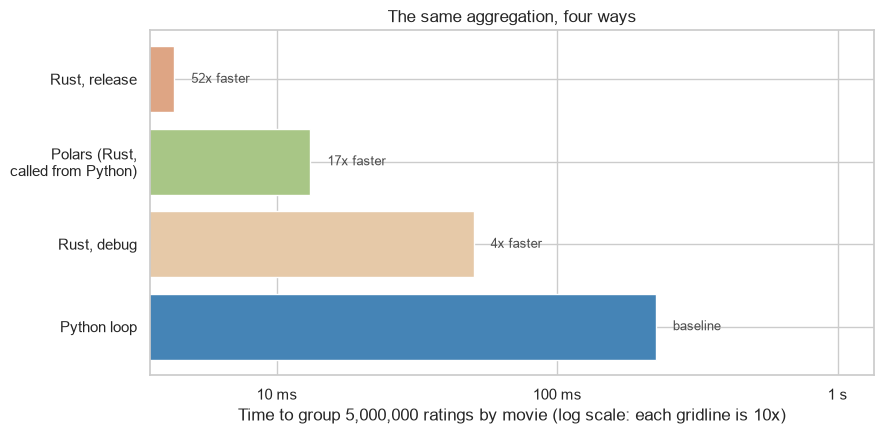

machine: arm64, 12 cores


In [21]:
measured = {
    "Python loop": python_aggregate,
    "Rust, debug": float(debug["aggregate_seconds"]),
    "Polars (Rust,\ncalled from Python)": polars_aggregate,
    "Rust, release": float(release["aggregate_seconds"]),
}
order = sorted(measured, key=measured.get, reverse=True)
colors = {
    "Python loop": "#4584b6",
    "Rust, debug": "#e6c9a8",
    "Polars (Rust,\ncalled from Python)": "#a8c686",
    "Rust, release": "#dea584",
}

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(order, [measured[k] for k in order], color=[colors[k] for k in order])
slowest = measured["Python loop"]
for bar, key in zip(bars, order):
    ax.text(
        bar.get_width() * 1.15,
        bar.get_y() + bar.get_height() / 2,
        (
            f"{slowest / measured[key]:.0f}x faster"
            if key != "Python loop"
            else "baseline"
        ),
        va="center",
        fontsize=9,
        color="0.3",
    )
ax.set(
    xscale="log",
    xlabel=f"Time to group {ROWS:,} ratings by movie (log scale: each gridline is 10x)",
    title="The same aggregation, four ways",
)
ax.xaxis.set_major_formatter(SECONDS)
ax.set_xlim(right=slowest * 6)
fig.tight_layout()
plt.show()

print(f"machine: {platform.machine()}, {os.cpu_count()} cores")

### Reading the chart

- **The axis is logarithmic**, so the bars understate the gap badly. Trust the
  labels, not the lengths.
- **The hand-written Rust loop is one to two orders of magnitude faster than
  the hand-written Python loop** — the chart says how much on your machine.
  Same algorithm, same data, same answer. The difference is that one of them
  was compiled to machine code and the other is being interpreted one bytecode
  at a time.
- **Compiling without `-O` throws away most of that.** Debug Rust is roughly
  ten times slower than release Rust — still ahead of the Python loop, but
  slower than simply calling Polars, and not the number anyone means when they
  say Rust is fast.
- **Polars lands within a small multiple of hand-written Rust, and you called
  it from Python.** That is the practical lesson of both notebooks: you do not
  have to choose between Python's ecosystem and Rust's speed, because the
  people who wrote your tools already made that choice for you.
- **One caveat, in Polars' favour.** The Rust loop cheats: movie IDs are small
  integers, so it uses them directly as array offsets. Polars has to hash real
  keys of arbitrary type, and it still finished in the same ballpark.


## 8. What to take away

| | Python | Rust |
|---|---|---|
| Mistakes are found | when the line runs | before the program runs |
| Variables | always rebindable | immutable unless `mut` |
| `b = a` | second name for one object | ownership moves; `a` is done |
| Memory is freed | by reference counting, plus a cycle collector | where the compiler wrote the `free` |
| Leaked cycles | possible, and common in long-running services | need `Rc` and `Weak` on purpose |
| Aliasing bugs | silent | one writer or many readers, enforced |
| Data races | possible; the GIL often hides them | a compile error |
| CPU-bound threads | one at a time | all cores |
| Getting something working | minutes | longer, and the compiler will argue |

**In one sentence:** Rust moves a whole class of runtime bug to compile time,
and the same rules that do that are what let it skip the garbage collector and
use every core — which is why the fast parts of your Python stack keep turning
out to be written in it.

You have already been using it. Polars from part 1 is Rust. So are `ruff` and
`uv`, the validation core of Pydantic, and Hugging Face's `tokenizers`. The
usual shape of a modern data tool is a Rust engine with a Python interface,
and that is a good shape: Python for the part that changes every day, Rust for
the part that runs five million times.

### Try it yourself

The files in `rust/examples/` are yours. Some things worth breaking:

1. In `02_variables.rs`, delete the `mut` from `rows_read` and read the error.
2. In `03_scope_memory.rs`, move `let _scratch = ...` out of the inner scope.
   Where does the `FREE` line go, and why?
3. In `04_ownership.rs`, change `summarize(&ratings)` to `summarize(ratings)`.
   The compiler will tell you what it wants — and what it wants is the
   difference between borrowing and owning.
4. In `06_threads.rs`, try 16 and 32 threads. The speedup stops. Find the
   number of cores your machine actually has and see where it stops.
5. Fix `wont_compile/shared_mutable_across_threads.rs` two ways: once by
   giving each thread its own subtotal, once with `std::sync::atomic::AtomicU64`.

Run everything from the terminal with:

```bash
make rust
make rust-errors
```
